## Ensemble Tecniques - Classification

In [112]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
data = pd.read_csv("./dataset/heart.csv")
df = data

In [78]:
data.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [93]:
df["HeartDiseaseorAttack"].unique()

array([0., 1.])

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

<Axes: >

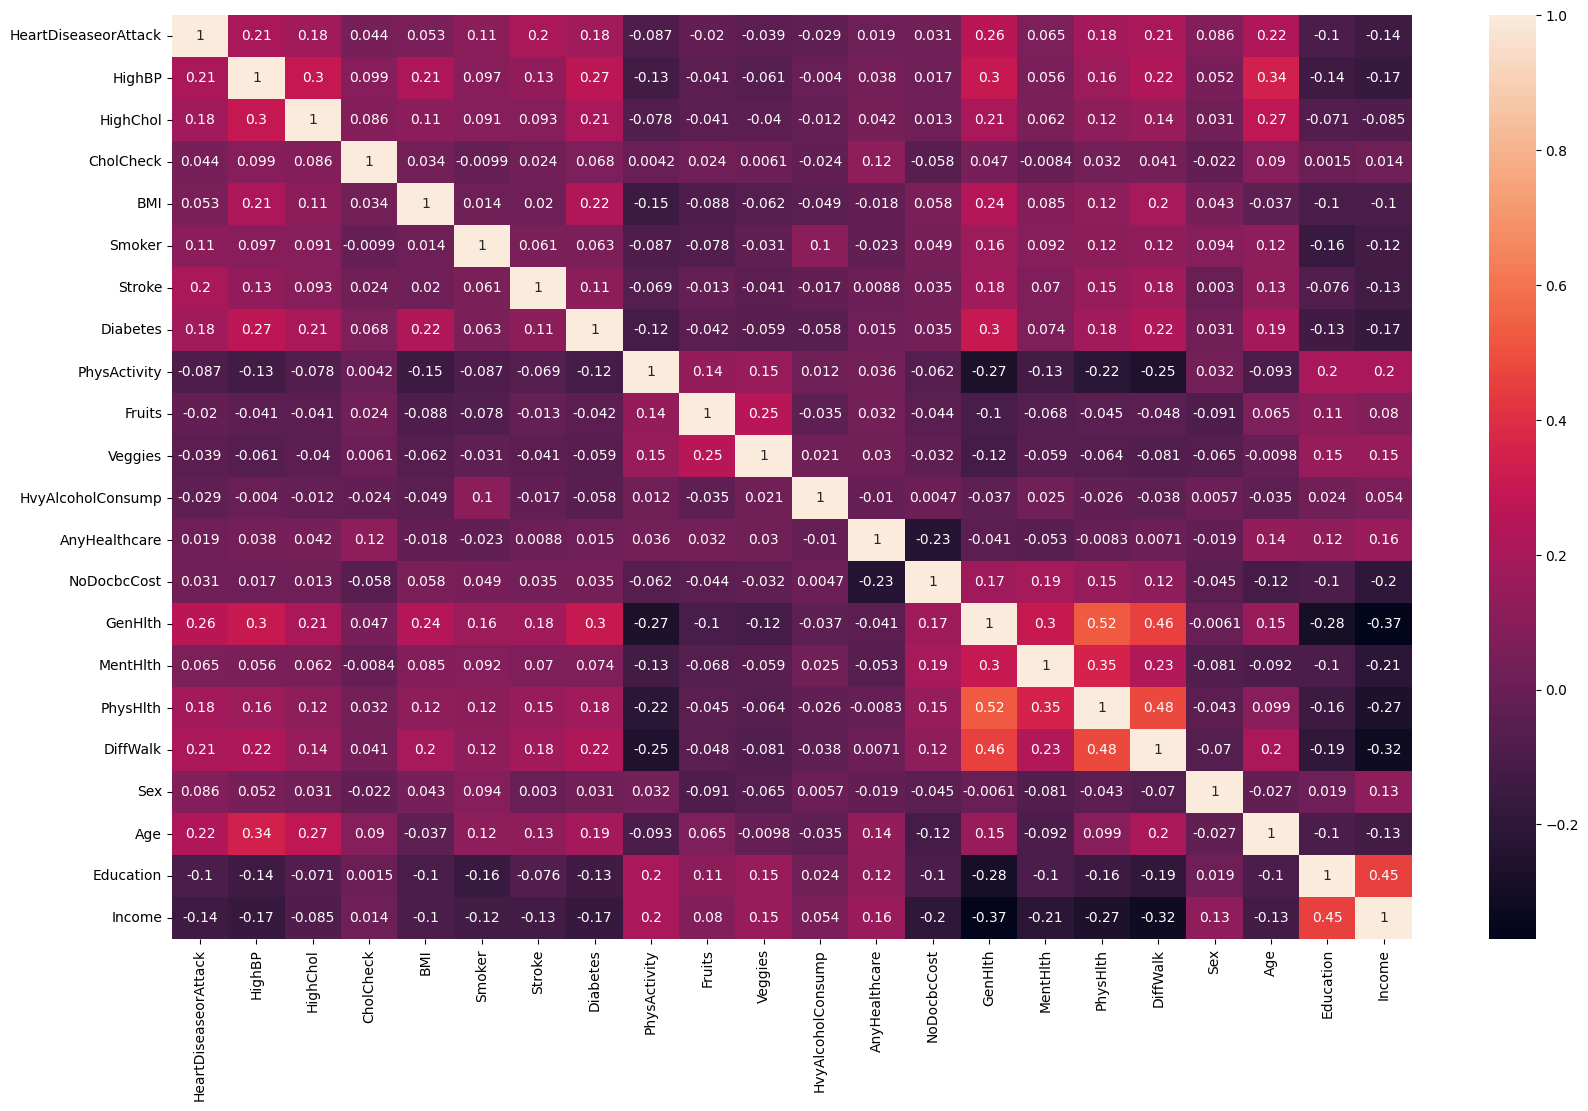

In [82]:
plt.figure(figsize=(20, 12))
correlated = df.corr(numeric_only=True)
sns.heatmap(data=correlated,annot = True)

In [84]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [85]:
y = df["HeartDiseaseorAttack"]
x = df[["HighBP", 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income']]

In [86]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

## Adaptive Boost

In [87]:
model = AdaBoostClassifier(n_estimators = 50,algorithm = "SAMME",random_state = 42)

In [88]:
model.fit(x_train,y_train)

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME', random_state=42)

In [89]:
test_pred = model.predict(x_test)

In [90]:
train_pred = model.predict(x_train)

In [91]:
accuracy_train = accuracy_score(y_train,train_pred)
accuracy_test = accuracy_score(y_test,test_pred)
accuracy_train

0.9065505755282245

In [92]:
accuracy_test

0.907481866918953

In [109]:
val = [0,0,0,21.5,0,0,1,1,1,1,0,1,1,1,1,1,1,0,21,1,0]
pred = grad_model.predict([val])
if pred == 1:
    print("you will have heart attack")
else:
    print("you will not have heart attack so live as you want")

you will not have heart attack so live as you want


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


## Gradient Boost

In [104]:
grad_model = GradientBoostingClassifier(n_estimators = 100,learning_rate = 0.1,max_depth = 3,random_state = 42)

In [105]:
grad_model.fit(x_train,y_train)

GradientBoostingClassifier(random_state=42)

In [114]:
grad_y_train_pred = grad_model.predict(x_train)
grad_y_test_pred = grad_model.predict(x_test)

In [115]:
grad_y_train_accuracy = accuracy_score(y_train,grad_y_train_pred)
grad_y_test_accuracy = accuracy_score(y_test,grad_y_test_pred)
grad_y_train_accuracy

0.9084033033743298

In [116]:
grad_y_test_accuracy

0.9084870703248187

### XGBoost

In [120]:
xg_model = XGBClassifier(n_estimators = 1000)
xg_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [121]:
xg_y_train_pred = xg_model.predict(x_train)
xg_y_test_pred = xg_model.predict(x_test)

In [122]:
xg_y_train_accuracy = accuracy_score(y_train,xg_y_train_pred)
xg_y_test_accuracy = accuracy_score(y_test,xg_y_test_pred)
xg_y_train_accuracy

0.9461033585619678

In [123]:
xg_y_test_accuracy

0.8997753074739829